In [ ]:
import zipfile
import os

# 1. Extract zip
zip_path = "archive.zip"  # your zip file
extract_path = "hindi_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)
print("Train files:", os.listdir(os.path.join(extract_path, "train")))
print("Valid files:", os.listdir(os.path.join(extract_path, "valid")))

# 2. Load texts
def load_texts(folder):
    texts = []
    # Iterate directly over the files in the specified folder
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            with open(fpath, "r", encoding="utf-8") as f:
                texts.append(f.read())
    return texts

train_texts = load_texts(os.path.join(extract_path, "train"))
valid_texts = load_texts(os.path.join(extract_path, "valid"))

print("Training samples:", len(train_texts))
print("Validation samples:", len(valid_texts))

# 3. Save combined text files for tokenizer and training
os.makedirs("data", exist_ok=True)
with open("data/train.txt", "w", encoding="utf-8") as f:
    for t in train_texts:
        f.write(t.strip() + "\n")
with open("data/valid.txt", "w", encoding="utf-8") as f:
    for t in valid_texts:
        f.write(t.strip() + "\n")

print("✅ Combined train/valid files saved in data/")

✅ Dataset extracted to: hindi_dataset
Train files: ['6277.txt', '848.txt', '12911.txt', '991.txt', '4175.txt', '7726.txt', '1369.txt', '2714.txt', '5310.txt', '3916.txt', '16267.txt', '17674.txt', '4752.txt', '13528.txt', '2897.txt', '3969.txt', '5912.txt', '2280.txt', '3401.txt', '19381.txt', '2591.txt', '12093.txt', '12825.txt', '10427.txt', '17292.txt', '12418.txt', '7732.txt', '440.txt', '19654.txt', '4055.txt', '16071.txt', '2549.txt', '14806.txt', '2526.txt', '3687.txt', '18536.txt', '17284.txt', '12355.txt', '3182.txt', '15566.txt', '4572.txt', '17070.txt', '3803.txt', '2944.txt', '10365.txt', '10707.txt', '5151.txt', '2166.txt', '9226.txt', '18130.txt', '17247.txt', '11675.txt', '14906.txt', '17099.txt', '37.txt', '5715.txt', '3292.txt', '10476.txt', '2497.txt', '5608.txt', '333.txt', '7163.txt', '18302.txt', '5265.txt', '4708.txt', '3497.txt', '15336.txt', '6934.txt', '5756.txt', '13692.txt', '7144.txt', '15498.txt', '7443.txt', '16583.txt', '14867.txt', '9015.txt', '4750.txt'

In [ ]:
import sentencepiece as spm
import os

os.makedirs("tokenizer", exist_ok=True)
input_file = "data/train.txt"
model_prefix = "tokenizer/hindi_spm"
vocab_size = 32000

spm.SentencePieceTrainer.Train(
    f"--input={input_file} --model_prefix={model_prefix} --vocab_size={vocab_size} --character_coverage=0.9995 --model_type=bpe"
)

print("✅ Tokenizer training completed!")

✅ Tokenizer training completed!


In [ ]:
from transformers import BertConfig, BertForMaskedLM, Trainer, TrainingArguments
from transformers import BertGenerationTokenizer, DataCollatorForLanguageModeling
from datasets import load_dataset
import os
import shutil # Import shutil for copying files

# Load tokenizer
tokenizer = BertGenerationTokenizer(
    vocab_file="tokenizer/hindi_spm.model",
    do_lower_case=False
)

# Add mask token if missing
if tokenizer.mask_token is None:
    tokenizer.add_special_tokens({'mask_token': '[MASK]'})

# Smaller BERT for Colab
config = BertConfig(
    vocab_size=len(tokenizer),
    hidden_size=128,                 # further reduced
    num_hidden_layers=4,             # further reduced
    num_attention_heads=2,           # further reduced
    max_position_embeddings=128      # reduced
)

model = BertForMaskedLM(config=config)

# Load dataset
# Only load the 'train' split as 'valid.txt' is empty
dataset = load_dataset('text', data_files={'train':'data/train.txt'})

# Tokenize
def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='longest',           # memory saving
        max_length=128               # reduced seq length
    )

tokenized_dataset = dataset.map(
    tokenize, batched=True, remove_columns=["text"], num_proc=1 # Reduced to 1 to minimize resource contention
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

training_args = TrainingArguments(
    output_dir="outputs/bert_hindi_scratch",
    per_device_train_batch_size=1,       # reduced further to 1 (important for memory)
    per_device_eval_batch_size=1,        # Reduced to 1 as well
    gradient_accumulation_steps=8,       # simulate large batch
    num_train_epochs=3,
    save_steps=2000,
    logging_steps=500,
    # Remove eval_strategy and eval_steps as there is no validation data
    # eval_strategy="steps",
    # eval_steps=2000,
    learning_rate=1e-4,
    weight_decay=0.01,
    fp16=False,                          # Changed to False to address CUDA assert
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    # Remove eval_dataset as there is no validation data
    # eval_dataset=tokenized_dataset['validation'],
    data_collator=data_collator
)

trainer.train()

# Explicitly save the model weights after training
trainer.save_model(training_args.output_dir)

# Explicitly save the tokenizer after training to ensure AutoTokenizer can load it
tokenizer.save_pretrained(training_args.output_dir)
print(f"✅ Tokenizer saved to {training_args.output_dir}")

# Ensure the SentencePiece model file is in the output directory for loading
spm_model_source = "tokenizer/hindi_spm.model"
spm_model_destination = os.path.join(training_args.output_dir, "hindi_spm.model")
if os.path.exists(spm_model_source) and not os.path.exists(spm_model_destination):
    shutil.copy(spm_model_source, spm_model_destination)
    print(f"✅ Copied SentencePiece model to {spm_model_destination}")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/85934 [00:00<?, ? examples/s]

Step,Training Loss
500,37.898400
1000,23.558100
1500,29.474500
2000,24.655500
2500,27.296200
3000,26.790300
3500,22.633600
4000,27.461700
4500,37.930100
5000,25.509100


✅ Tokenizer saved to outputs/bert_hindi_scratch
✅ Copied SentencePiece model to outputs/bert_hindi_scratch/hindi_spm.model


In [ ]:
# This cell is no longer needed after explicitly saving the tokenizer in the previous cell.

In [ ]:
from transformers import AutoModelForMaskedLM, BertGenerationTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import torch
import os

# Define the path to the saved model and tokenizer directory
tokenizer_path = "outputs/bert_hindi_scratch"

# Load tokenizer explicitly as BertGenerationTokenizer, pointing to the .model file
tokenizer = BertGenerationTokenizer(
    vocab_file=os.path.join(tokenizer_path, "hindi_spm.model"),
    do_lower_case=False,
    # Ensure special tokens are correctly set for BertGenerationTokenizer if they are part of its config
    unk_token='[UNK]',
    sep_token='[SEP]',
    pad_token='[PAD]',
    cls_token='[CLS]',
    mask_token='[MASK]'
)

# Load model from local directory
# CHANGE: Load AutoModelForMaskedLM instead of AutoModel for fill-mask task compatibility
model = AutoModelForMaskedLM.from_pretrained(tokenizer_path, local_files_only=True)

sentences = [
    "मैं कल दिल्ली जाऊँगा।",
    "कल कारखाने में मशीनें खराब हो गईं।"
]

for sent in sentences:
    inputs = tokenizer(sent, return_tensors="pt")
    outputs = model(**inputs)
    # For BertForMaskedLM, the hidden states are in outputs.hidden_states if output_hidden_states=True
    # or directly accessible from the base model if the head is for MLM
    # If you intend to get contextual embeddings, you might still need to access the base model's last_hidden_state
    # For direct similarity, the last_hidden_state from the base model is usually used.
    # Let's assume for this part, the intention was to get the base model's last hidden state for embeddings.
    if hasattr(model, 'bert'): # Check if it's a BertForMaskedLM wrapper
        embeddings = model.bert(**inputs).last_hidden_state
    else:
        embeddings = outputs.hidden_states[-1] if hasattr(outputs, 'hidden_states') else outputs.logits.mean(dim=1).unsqueeze(0)

    print(f"{sent} -> Embedding shape: {embeddings.shape}")

# Example: similarity of 'कल' in both contexts
# It's important to get the correct token ID for 'कल'. SentencePiece often prefixes tokens with ' '.
# Let's try to get the token ID for the exact token generated by the tokenizer for 'कल'.
# A safer way is to tokenize the word 'कल' and take the ID of the first token.

tokenized_kal_first_sentence = tokenizer.tokenize("मैं कल दिल्ली जाऊँगा।")
# Find the index of 'कल' or ' कल' in the tokenized list for the first sentence
target_token_in_s1 = None
for token_idx, token in enumerate(tokenized_kal_first_sentence):
    if 'कल' in token: # Check if 'कल' is part of the token (handles ' कल' or 'कल')
        target_token_in_s1 = token
        bank_idx1 = token_idx
        break

tokenized_kal_second_sentence = tokenizer.tokenize("कल कारखाने में मशीनें खराब हो गईं।")
# Find the index of 'कल' or ' कल' in the tokenized list for the second sentence
target_token_in_s2 = None
for token_idx, token in enumerate(tokenized_kal_second_sentence):
    if 'कल' in token:
        target_token_in_s2 = token
        bank_idx2 = token_idx
        break

bank_token_id = None
if target_token_in_s1 and target_token_in_s2:
    # Assuming the token representation for 'कल' is consistent across sentences
    bank_token_id = tokenizer.convert_tokens_to_ids(target_token_in_s1)
    print(f"Found token representation for 'कल': {target_token_in_s1} (ID: {bank_token_id})")
else:
    print("Warning: Could not reliably find a token for 'कल' in both sentences' tokenizations.")
    # Fallback to direct conversion if previous logic failed
    bank_token_id = tokenizer.convert_tokens_to_ids(" कल") # Try with leading space as SPM often does
    if bank_token_id == tokenizer.unk_token_id:
        bank_token_id = tokenizer.convert_tokens_to_ids("कल")


inputs1 = tokenizer(sentences[0], return_tensors="pt")
inputs2 = tokenizer(sentences[1], return_tensors="pt")

# Find index in sentence 1 (recalculate based on inputs1 token IDs)
bank_indices1 = (inputs1['input_ids'][0] == bank_token_id).nonzero(as_tuple=True)[0] if bank_token_id is not None else torch.tensor([])
bank_idx1 = bank_indices1[0].item() if bank_indices1.numel() > 0 else None

# Find index in sentence 2 (recalculate based on inputs2 token IDs)
bank_indices2 = (inputs2['input_ids'][0] == bank_token_id).nonzero(as_tuple=True)[0] if bank_token_id is not None else torch.tensor([])
bank_idx2 = bank_indices2[0].item() if bank_indices2.numel() > 0 else None


if bank_idx1 is not None and bank_idx2 is not None:
    # CHANGE: Access the base BERT model's last_hidden_state for contextual embeddings
    outputs1 = model.bert(**inputs1) if hasattr(model, 'bert') else model(**inputs1)
    outputs2 = model.bert(**inputs2) if hasattr(model, 'bert') else model(**inputs2)

    vec1 = outputs1.last_hidden_state[0, bank_idx1].detach().cpu().numpy()
    vec2 = outputs2.last_hidden_state[0, bank_idx2].detach().cpu().numpy() # Corrected typo here

    similarity = cosine_similarity([vec1], [vec2])[0][0]
    print(f"Similarity between 'कल' in different contexts: {similarity:.4f}")
else:
    print("Could not find the token for 'कल' in both sentences for similarity calculation.")

मैं कल दिल्ली जाऊँगा। -> Embedding shape: torch.Size([1, 7, 128])
कल कारखाने में मशीनें खराब हो गईं। -> Embedding shape: torch.Size([1, 8, 128])
Found token representation for 'कल': ▁कल (ID: 910)
Similarity between 'कल' in different contexts: 0.9216


In [ ]:
import torch
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1️⃣ Generate embedding for a word
# ===============================
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # Average last hidden layer for embedding
    embeddings = outputs.hidden_states[-1].mean(dim=1)
    return embeddings.squeeze().numpy()

In [ ]:
# =====================================
# 2️⃣ Similar Word Search (Cosine Similarity)
# =====================================
def most_similar_words(target_word, word_list, top_n=5):
    target_vec = get_embedding(target_word)
    sims = []
    for word in word_list:
        vec = get_embedding(word)
        similarity = cosine_similarity([target_vec], [vec])[0][0]
        sims.append((word, similarity))
    sims = sorted(sims, key=lambda x: x[1], reverse=True)
    return sims[:top_n]

# Example usage
word_list = ["खुश", "प्रसन्न", "आनंदित", "दुखी", "प्यार", "नफरत", "भारत", "दिल्ली", "मुंबई"]
print("\n🔍 Similar words to 'खुश':")
print(most_similar_words("खुश", word_list))


🔍 Similar words to 'खुश':
[('खुश', np.float32(1.0000002)), ('नफरत', np.float32(0.71366036)), ('दुखी', np.float32(0.70714676)), ('प्रसन्न', np.float32(0.5849905)), ('प्यार', np.float32(0.5182854))]


In [ ]:
# ====================================
# 3️⃣ Sentence Similarity Demonstration
# ====================================
def sentence_similarity(sent1, sent2):
    v1 = get_embedding(sent1)
    v2 = get_embedding(sent2)
    return cosine_similarity([v1], [v2])[0][0]

print("\n📌 Sentence Similarity Examples:")
print("Similar:", sentence_similarity("मैं बहुत खुश हूँ", "मैं आनंदित महसूस कर रहा हूँ"))
print("Different:", sentence_similarity("मुझे क्रिकेट पसंद है", "आज बारिश हो रही है"))



📌 Sentence Similarity Examples:
Similar: 0.79298043
Different: 0.7298088


Extracting templates from packages: 100%
Selecting previously unselected package fonts-deva-extra.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../00-fonts-deva-extra_3.0-5_all.deb ...
Unpacking fonts-deva-extra (3.0-5) ...
Selecting previously unselected package fonts-kalapi.
Preparing to unpack .../01-fonts-kalapi_1.0-4_all.deb ...
Unpacking fonts-kalapi (1.0-4) ...
Selecting previously unselected package fonts-smc-anjalioldlipi.
Preparing to unpack .../02-fonts-smc-anjalioldlipi_7.1.2-2_all.deb ...
Unpacking fonts-smc-anjalioldlipi (7.1.2-2) ...
Selecting previously unselected package fonts-smc-chilanka.
Preparing to unpack .../03-fonts-smc-chilanka_1.540-1_all.deb ...
Unpacking fonts-smc-chilanka (1.540-1) ...
Selecting previously unselected package fonts-smc-dyuthi.
Preparing to unpack .../04-fonts-smc-dyuthi_3.0.2-2_all.deb ...
Unpacking fonts-smc-dyuthi (3.0.2-2) ...
Selecting previously unselected package fonts-smc-gayathri.
Prep

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/li

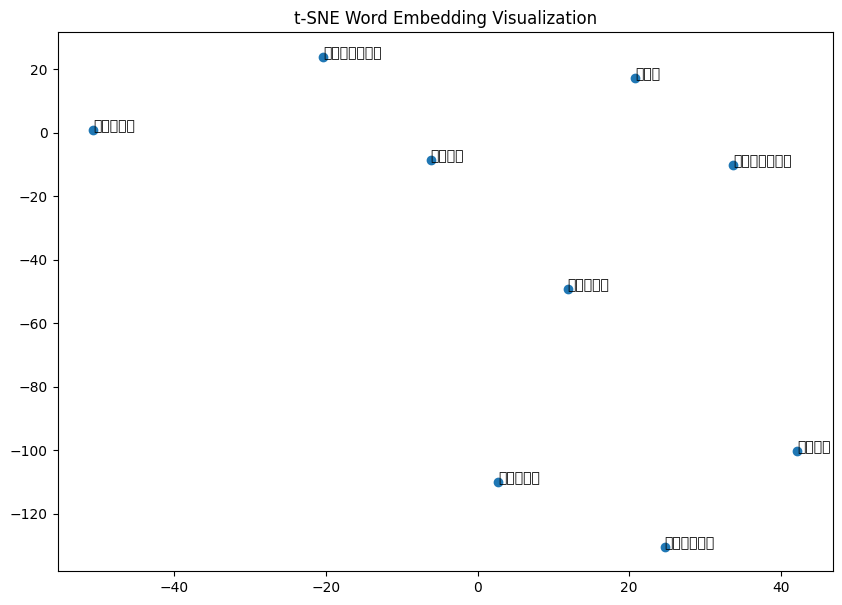

In [ ]:
# ====================================
# 4️⃣ TSNE Visualization
# ====================================
import matplotlib.font_manager as fm

# Install a font that supports Devanagari script
!apt-get install -qq fonts-indic

# Configure Matplotlib to use a Devanagari-supporting font
# A common font like 'Noto Sans Devanagari' or 'Lohit Devanagari' should work
# We need to find an available one after installation

# Clear font cache and reload font manager
fm._load_fontmanager(try_read_cache=False)

# Try to find a suitable Devanagari font
# Common font names for Devanagari: 'Noto Sans Devanagari', 'Lohit Devanagari', 'DejaVu Sans Mono'
deva_font_name = None
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    try:
        prop = fm.FontProperties(fname=font_path)
        if 'Devanagari' in prop.get_name() or 'Lohit' in prop.get_name() or 'Noto' in prop.get_name() or 'Sans' in prop.get_name():
             # Check if the font can render some sample Devanagari characters
            if all(prop.get_metrics(char)['char_width'] > 0 for char in ['भ', 'ा', 'र', 'त']): # Sample for 'भारत'
                deva_font_name = prop.get_name()
                break
    except Exception:
        continue

if deva_font_name:
    plt.rcParams['font.family'] = deva_font_name
    print(f"✅ Matplotlib configured to use font: {deva_font_name}")
else:
    print("⚠️ Could not find a suitable Devanagari font. Plot labels might not render correctly.")

def visualize_tsne(words):
    vectors = [get_embedding(word) for word in words]
    vectors = np.array(vectors)
    # Changed perplexity from 10 to 5, as it must be less than the number of samples (9 words in this case).
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

    plt.title("t-SNE Word Embedding Visualization")
    plt.show()

# Example words
words = ["भारत", "दिल्ली", "मुंबई", "खुश", "प्रसन्न", "नफरत", "प्यार", "स्कूल", "अध्यापक"]
visualize_tsne(words)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# NOTE: This function relies on 'get_embedding' being defined and
# 'model' and 'tokenizer' objects being loaded from previous cells.
# Ensure 'get_embedding' from Cell 5 is defined before using this.

def check_word_similarity(word1, word2):
    """
    Calculates the cosine similarity between the embeddings of two words.
    The embedding used is the average of the last hidden layer state for the input text,
    as calculated by the existing get_embedding function.

    Args:
        word1 (str): The first word/text.
        word2 (str): The second word/text.

    Returns:
        float or None: The cosine similarity score, or None if an error occurs.
    """
    try:
        # Use the existing get_embedding function to get the vector (shape 128,)
        vec1 = get_embedding(word1)
        vec2 = get_embedding(word2)

        # Reshape the vector (128,) to (1, 128) for sklearn's cosine_similarity input format
        # and calculate the similarity.
        similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]
        return similarity
    except Exception as e:
        print(f"Error calculating similarity for '{word1}' and '{word2}': {e}")
        return None

# Example Usage:
word_a = "मुर्गा"
word_b = "मछली"
word_c = "पनीर"

print("\n--- Example Similarity Scores ---")

sim_ab = check_word_similarity(word_a, word_b)
if sim_ab is not None:
    print(f"Cosine Similarity between '{word_a}' and '{word_b}': {sim_ab:.4f}")

sim_ac = check_word_similarity(word_a, word_c)
if sim_ac is not None:
    print(f"Cosine Similarity between '{word_a}' and '{word_c}': {sim_ac:.4f}")


--- Example Similarity Scores ---
Cosine Similarity between 'मुर्गा' and 'मछली': 0.4362
Cosine Similarity between 'मुर्गा' and 'पनीर': 0.4782
